# 02 — SMS Spam: Feature Engineering and Classification

Builds on notebook 01. Twelve numerical features are engineered from raw message text
and used to fit a decision tree and a random forest.

**The constraint that defines this project:** no vectoriser, no bag of words, no TF-IDF.
The classifier never sees *which* words a message contains — only its shape. That is a
deliberate limitation with a real cost, quantified in the LIMITATIONS section at the end.

**Pipeline order, and why it is this order:**

1. Load with the encoding-safe loader.
2. **Drop the 403 exact duplicates — before the split, not after.**
3. Engineer the 12 features.
4. Label-encode the target.
5. Stratified 80/20 split, `random_state=42`.
6. **Scale after splitting**, with statistics fitted on the training partition only.
7. Fit the models; report precision, recall and F1 **for the spam class**.

Steps 2 and 6 are the two places this pipeline could leak, and both are enforced
structurally rather than by remembering — see section 4.

**Section order:** imports → data loading → EDA → preprocessing → modelling → evaluation.

## 1. Imports

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.dummy import DummyClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, precision_recall_curve,
    average_precision_score,
)

from src.utils.loader import read_csv_safe
from src.utils.redaction import redact, safe_sample
from src.utils.plotstyle import CLASS_COLORS, SERIES, INK_SECONDARY, apply_style, despine, annotate_bars
from src.features.spam_features import FEATURE_ORDER, build_feature_frame
from src.preprocessing.template import PreprocessingTemplate, split_dataset

apply_style()
pd.set_option("display.width", 110)
pd.set_option("display.max_columns", 30)

RANDOM_STATE = 42

> **`random_state=42`.** Every stochastic step in this notebook — the split, the tree,
> the forest — takes the same fixed seed. The value is arbitrary; fixing it is not.
> Without it, the split changes on every run and so does every number below, which
> makes the difference between two models indistinguishable from the difference
> between two runs of the same model.

## 2. Data loading

In [2]:
raw = read_csv_safe(
    ROOT / "data" / "SMSSpamCollection.tsv",
    sep="\t", header=None, names=["label", "message"], quoting=3,
)
sms = raw.frame
print(f"\nencoding used: {raw.encoding}   shape: {sms.shape}")
display(safe_sample(sms, n=3, group_by="label", random_state=3).reset_index(drop=True))

Loaded SMSSpamCollection.tsv: 5,574 rows x 2 cols using encoding 'utf-8'

encoding used: utf-8   shape: (5574, 2)


,label,message
0,ham,<NAME> fever:) now fine:)
1,ham,I reach home safe n sound liao...
2,ham,<NAME> buying... But school got offer <NUM> pl...
3,spam,No <NUM> POLYPHONIC tone <NUM> ur mob every we...
4,spam,lyricalladie(<NUM>/F) is inviting you to be he...
5,spam,<<NAME> from <NUM>>FREE entry into our <MONEY>...


Printed rows are redacted — see notebook 01 for why. `quoting=3` disables quote
handling; message bodies contain bare `"` characters that would otherwise swallow
whole rows.

## 3. EDA — the two facts that shape every decision below

Notebook 01 covers exploration in full. Two findings from it drive the choices in this
notebook, so they are re-established here rather than assumed.

In [3]:
before = len(sms)
n_dupes = int(sms.duplicated(subset=["label", "message"]).sum())
balance = sms["label"].value_counts(normalize=True)

print(f"rows                 : {before:,}")
print(f"exact duplicates     : {n_dupes:,}  ({n_dupes / before:.1%})")
print(f"majority class       : {balance.idxmax()} at {balance.max():.1%}")
print(f"minority class       : {balance.idxmin()} at {balance.min():.1%}")
print()
print(f"=> a model predicting '{balance.idxmax()}' for every row scores "
      f"{balance.max():.1%} accuracy and catches zero spam.")

rows                 : 5,574
exact duplicates     : 403  (7.2%)
majority class       : ham at 86.6%
minority class       : spam at 13.4%

=> a model predicting 'ham' for every row scores 86.6% accuracy and catches zero spam.


**Fact 1 — 403 exact duplicates (7.2%).** Dropped in section 4, before the split.

**Fact 2 — 86.6% of rows are one class.** This makes accuracy near-meaningless as a
headline metric, and it is why section 6 leads with precision/recall/F1 for the spam
class. It is also the reason the split is stratified.

## 4. Preprocessing

### 4.1 Feature engineering

The 12 features are defined in `src/features/spam_features.py`, each as a standalone
function applied column-wise. They live in a module rather than in this notebook so
that notebook 01, this notebook and `tests/test_spam_features.py` share exactly one
definition of each — a threshold tweaked here cannot silently disagree with the one
the tests pin.

In [4]:
features = build_feature_frame(sms["message"])
frame = pd.concat([sms[["label", "message"]], features], axis=1)

print(f"{len(FEATURE_ORDER)} features:")
for i, name in enumerate(FEATURE_ORDER, 1):
    print(f"  {i:>2}. {name}")
print(f"\nframe: {features.shape[0]:,} rows x {features.shape[1]} features")
print("missing values:", int(features.isna().sum().sum()))

12 features:
   1. char_length
   2. word_count
   3. mean_word_length
   4. digit_count
   5. digit_ratio
   6. uppercase_ratio
   7. all_caps_word_count
   8. exclamation_count
   9. currency_symbol_count
  10. non_alnum_count
  11. has_url_like
  12. has_long_digit_run

frame: 5,574 rows x 12 features
missing values: 0


### 4.2 Label encoding

`LabelEncoder` sorts classes alphabetically, so `ham → 0` and `spam → 1`. That is the
mapping we want and not a coincidence worth relying on silently, so it is asserted
below: **spam must be the positive class (1)**, or every `pos_label=1` metric in
section 6 would silently report the wrong class.

In [5]:
encoder = LabelEncoder()
y_all = pd.Series(encoder.fit_transform(frame["label"]), name="is_spam")

mapping = dict(zip(encoder.classes_, encoder.transform(encoder.classes_)))
print("label encoding:", mapping)
assert mapping["spam"] == 1, "spam must encode to 1 -- the positive class"
SPAM, HAM = 1, 0

label encoding: {'ham': 0, 'spam': 1}


### 4.3 De-duplicate, then split

**This is the ordering that matters most in the notebook.**

If the 403 duplicates survive into the split, the same message body can land in both
partitions — one copy trains, the other tests. The model is then scored on rows it has
memorised verbatim, and the held-out number stops measuring generalisation and starts
measuring memorisation. It would look like a *better* result, which is what makes the
mistake dangerous.

`split_dataset` de-duplicates *and then* splits, in that order, by construction. It
returns a `TrainingPartition` — a type that only it can produce, and the only thing the
preprocessing template will accept for fitting. Handing the template the full dataset
raises `TypeError` rather than quietly leaking, so the leaky spelling of this cell
fails at runtime instead of returning a nicer score.

Parameters:

- `duplicate_subset=["label", "message"]` — de-duplicate on the raw text, not on the
  engineered features. Two genuinely different messages could share all 12 feature
  values by coincidence; those are not duplicates and dropping them would throw away
  real data.
- `keep_columns=FEATURE_ORDER` — the model matrix is the twelve features and nothing
  else. `label` and `message` are needed *for* de-duplication but must never reach the
  model: `label` is the target in string form, which would be a perfect leak, and
  `message` is the raw text this project is committed to not using. Naming the model
  columns up front means there is never a moment where the wrong frame could be passed
  to `fit`. They come back as `split.train_meta` / `split.test_meta`, index-aligned,
  for the error analysis in section 6.5.
- `test_size=0.2` — the brief's 80/20. At 5,171 de-duplicated rows this leaves ~1,035
  test rows of which ~131 are spam: enough that spam recall moves in increments under
  one point.
- `stratify=True` — preserves the 13.4% spam rate in both halves. On an imbalanced
  target an unstratified split can hand the test set a materially different class prior
  than the model trained against.
- `random_state=42` — reproducibility.

In [6]:
model_frame = frame[["label", "message"] + list(FEATURE_ORDER)]

split = split_dataset(
    model_frame,
    y_all,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=True,
    drop_duplicates=True,
    duplicate_subset=["label", "message"],
    keep_columns=list(FEATURE_ORDER),
)
print(split.describe())

rows in            : 5,574
exact duplicates   : 403 dropped before the split
train / test       : 4,136 / 1,035
class balance      :
    0            train 87.38%   test 87.34%
    1            train 12.62%   test 12.66%


In [7]:
X_train_raw = split.train.X
X_test_raw = split.test_X
y_train, y_test = split.train.y, split.test_y

# The model matrix is the twelve features and nothing else.
assert list(X_train_raw.columns) == list(FEATURE_ORDER)
assert "message" not in X_train_raw.columns and "label" not in X_train_raw.columns
assert list(split.train_meta.columns) == ["label", "message"]

print(f"train {X_train_raw.shape}   test {X_test_raw.shape}")
print(f"train spam rate {y_train.mean():.3%}   test spam rate {y_test.mean():.3%}")
print(f"held aside for error analysis: {list(split.test_meta.columns)}")

train (4136, 12)   test (1035, 12)
train spam rate 12.621%   test spam rate 12.657%
held aside for error analysis: ['label', 'message']


### 4.4 Scale after splitting

The scaler is fitted on the **training partition only** and then applied to both halves.
Fitting it on the full dataset before splitting is the classic leak: the test rows'
mean and variance would be baked into the transformation applied to the training data.

`PreprocessingTemplate.fit()` accepts only a `TrainingPartition`, so this cannot be
done the wrong way round here — the correct order is the only one that runs. The cell
after this one verifies it held, rather than trusting the claim.

Tree models do not need scaled inputs — a split threshold is invariant to a monotone
rescaling — so this step changes nothing for the two estimators in section 5. It is
kept because the brief calls for it, because it makes the feature matrix directly
comparable across features, and because the moment any distance- or magnitude-based
model is added it becomes load-bearing.

In [8]:
prep = PreprocessingTemplate(numeric_strategy="median", scale=True)
prep.fit(split.train)          # only a TrainingPartition is accepted here

X_train = prep.transform(X_train_raw)
X_test = prep.transform(X_test_raw)
print(prep.summary())

PreprocessingTemplate fitted on 4,136 training rows
  numeric (12): char_length, word_count, mean_word_length, digit_count, digit_ratio, uppercase_ratio, all_caps_word_count, exclamation_count, currency_symbol_count, non_alnum_count, has_url_like, has_long_digit_run
  categorical (0): -
  output columns: 12
  scaler means (train only): char_length=79.39, word_count=15.43, mean_word_length=4.259, digit_count=2.22, digit_ratio=0.01841, uppercase_ratio=0.08747 ...


In [9]:
# Verify the claim rather than asserting it in prose: the fitted mean must equal the
# training-partition mean, and must differ from the full-dataset mean.
full_features = features[list(FEATURE_ORDER)]
train_mean = X_train_raw.mean().to_numpy()
full_mean = full_features.mean().to_numpy()
fitted_mean = prep.scaler_.mean_[
    [prep.numeric_columns_.index(c) for c in FEATURE_ORDER]
]

print("fitted mean == train-partition mean :", np.allclose(fitted_mean, train_mean))
print("fitted mean == full-dataset mean    :", np.allclose(fitted_mean, full_mean))
print()
print(pd.DataFrame({
    "fitted (train only)": fitted_mean,
    "train partition": train_mean,
    "full dataset": full_mean,
}, index=list(FEATURE_ORDER)).round(4).head(6))
print()
print("train columns standardised to mean 0:",
      np.allclose(X_train.mean().to_numpy(), 0, atol=1e-9))
print("test columns NOT re-centred (mean != 0):",
      not np.allclose(X_test.mean().to_numpy(), 0, atol=1e-2))

fitted mean == train-partition mean : True
fitted mean == full-dataset mean    : False

                  fitted (train only)  train partition  full dataset
char_length                   79.3943          79.3943       80.4783
word_count                    15.4333          15.4333       15.5917
mean_word_length               4.2595           4.2595        4.2768
digit_count                    2.2195           2.2195        2.3834
digit_ratio                    0.0184           0.0184        0.0193
uppercase_ratio                0.0875           0.0875        0.0908

train columns standardised to mean 0: True
test columns NOT re-centred (mean != 0): True


The last two lines are the check that matters. Training columns come out at mean 0
because the scaler was fitted on them. **Test columns do not** — if they did, the
scaler would have been re-fitted on the test data, which is the leak this whole
section exists to prevent.

## 5. Modelling

Two estimators, plus a baseline to measure them against.

**`DummyClassifier(strategy="most_frequent")`** — the do-nothing model. Included so
that section 6's accuracy figure has something to be compared against; without it, 87%
accuracy reads as a result rather than as the floor.

**`DecisionTreeClassifier`** — left unpruned (no `max_depth`). An unpruned tree drives
training accuracy to 1.0 by memorising, so the train/test gap it produces is
informative in itself. Pruning it would give a better model but a less legible
demonstration, and the forest is where the better model comes from.

**`RandomForestClassifier(n_estimators=200)`** — 200 trees per the brief. More trees
monotonically reduce variance with no overfitting risk, at linear cost; the returns
flatten well before 200, so this is comfortably into the flat region.

**`class_weight` is deliberately left at `None`** on both. With 13.4% spam there is a
real case for `class_weight="balanced"`, and it would likely trade precision for
recall. It is omitted so the headline numbers describe the feature set rather than a
threshold policy layered on top; section 6 shows the precision/recall trade-off curve
instead, which is the more honest way to present that choice.

In [10]:
models = {
    "Baseline (most frequent)": DummyClassifier(strategy="most_frequent"),
    "Decision tree": DecisionTreeClassifier(random_state=RANDOM_STATE),
    "Random forest (200 trees)": RandomForestClassifier(
        n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1
    ),
}

fitted = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    fitted[name] = model
    print(f"fitted {name}")

fitted Baseline (most frequent)
fitted Decision tree


fitted Random forest (200 trees)


## 6. Evaluation

### 6.1 Headline metrics — precision, recall and F1 for the SPAM class

In [11]:
rows = []
for name, model in fitted.items():
    pred = model.predict(X_test)
    train_pred = model.predict(X_train)
    rows.append({
        "Model": name,
        "Precision (spam)": precision_score(y_test, pred, pos_label=SPAM, zero_division=0),
        "Recall (spam)": recall_score(y_test, pred, pos_label=SPAM, zero_division=0),
        "F1 (spam)": f1_score(y_test, pred, pos_label=SPAM, zero_division=0),
        "Accuracy": accuracy_score(y_test, pred),
        "Train F1 (spam)": f1_score(y_train, train_pred, pos_label=SPAM, zero_division=0),
    })

results = pd.DataFrame(rows)
display(results.set_index("Model").round(4))

,Precision (spam),Recall (spam),F1 (spam),Accuracy,Train F1 (spam)
Model,,,,,
Baseline (most frequent),0.0000,0.0000,0.0000,0.8734,0.0
Decision tree,0.9219,0.9008,0.9112,0.9778,1.0
Random forest (200 trees),0.9916,0.9008,0.9440,0.9865,1.0


**Random forest: spam precision 0.992, recall 0.901, F1 0.944.** The decision tree
reaches the same recall with much worse precision (0.922), so the forest's advantage
is almost entirely in false positives — the error type section 6.2 argues is the
costlier one.

For scale, notebook 01 found that a **single-threshold rule on `digit_count` alone
reaches spam F1 0.897**. The full twelve-feature forest adds ~4.7 points on top of
that. That is a real improvement and a modest one, and quoting 0.944 without the 0.897
next to it would make the feature set look far more decisive than it is.

The train/test gap on the decision tree is the other thing to note: it fits the
training set essentially perfectly and drops on held-out data, which is what an
unpruned tree does. The forest's averaging is what closes most of that gap.

### On accuracy — read this before quoting the accuracy column

**Accuracy is near-meaningless on this dataset and is printed only to be dismissed.**

86.6% of the corpus is `ham` (87.4% after de-duplication). The `DummyClassifier` row
above shows the consequence directly: predicting `ham` for every single message scores
**~87% accuracy while catching zero spam** — precision, recall and F1 for the spam
class are all exactly 0.

So a model at 97% accuracy is not "10 points better than nothing". Nearly all of that
87% is free. The only numbers on that table worth reading are the three spam-class
columns, because they are computed **only over the rows that matter** — a spam message
that gets through is a false negative and a legitimate message sent to the spam folder
is a false positive, and neither is visible in an accuracy figure dominated by the ham
the model gets right by default.

This is why the brief specifies precision, recall and F1 for the spam class as the
headline metrics, and it is a completely general point about imbalanced problems.

In [12]:
best_name = results.loc[results["F1 (spam)"].idxmax(), "Model"]
best = fitted[best_name]
print(f"best by spam F1: {best_name}\n")
print(classification_report(y_test, best.predict(X_test),
                            target_names=["ham", "spam"], digits=4))

best by spam F1: Random forest (200 trees)

              precision    recall  f1-score   support

         ham     0.9858    0.9989    0.9923       904
        spam     0.9916    0.9008    0.9440       131

    accuracy                         0.9865      1035
   macro avg     0.9887    0.9498    0.9682      1035
weighted avg     0.9865    0.9865    0.9862      1035



### 6.2 Confusion matrices

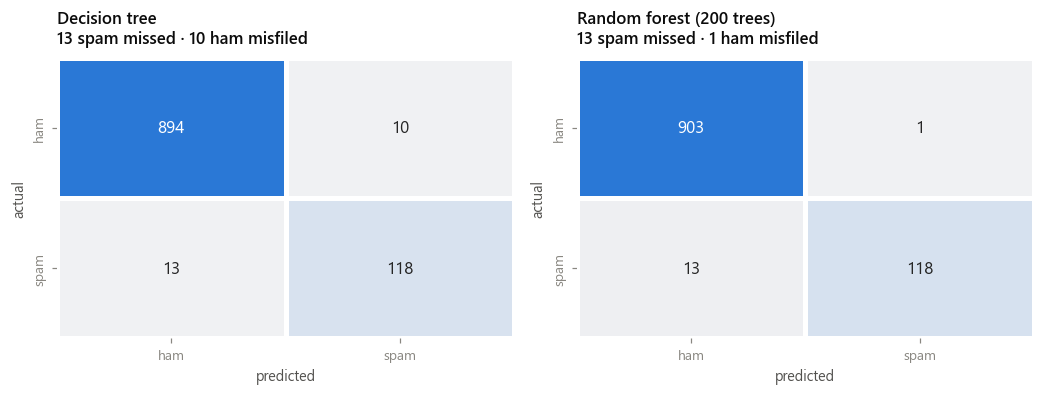

In [13]:
show = ["Decision tree", "Random forest (200 trees)"]
fig, axes = plt.subplots(1, 2, figsize=(9.6, 3.7))

for ax, name in zip(axes, show):
    cm = confusion_matrix(y_test, fitted[name].predict(X_test))
    sns.heatmap(cm, annot=True, fmt=",d", cbar=False, ax=ax,
                cmap=sns.light_palette(SERIES[0], as_cmap=True),
                xticklabels=["ham", "spam"], yticklabels=["ham", "spam"],
                annot_kws={"fontsize": 11}, linewidths=2, linecolor="white")
    tn, fp, fn, tp = cm.ravel()
    ax.set_title(f"{name}\n{fn} spam missed · {fp} ham misfiled")
    ax.set_xlabel("predicted")
    ax.set_ylabel("actual")
    ax.grid(False)

plt.tight_layout()
plt.show()

The two error types are not interchangeable. A **false negative** (bottom-left) is
spam that reached the inbox — an annoyance. A **false positive** (top-right) is a
legitimate message diverted to the spam folder — potentially a missed appointment or
a message from a family member. In a deployed filter the second is far more costly,
which argues for tuning toward precision even at some cost in recall.

### 6.3 Precision–recall trade-off

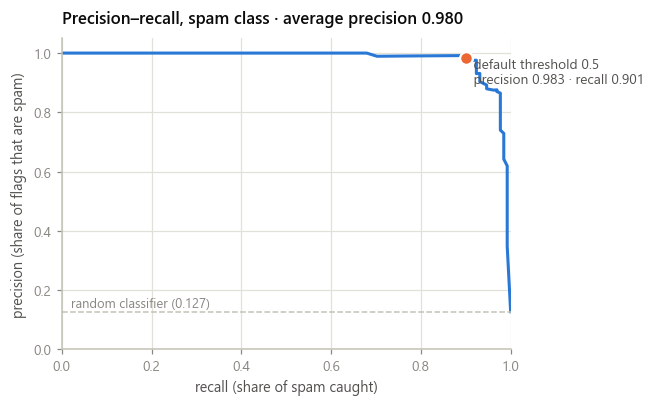

In [14]:
forest = fitted["Random forest (200 trees)"]
probabilities = forest.predict_proba(X_test)[:, SPAM]
precision, recall, thresholds = precision_recall_curve(y_test, probabilities, pos_label=SPAM)
ap = average_precision_score(y_test, probabilities, pos_label=SPAM)

fig, ax = plt.subplots(figsize=(6.0, 3.8))
ax.plot(recall, precision, color=SERIES[0], linewidth=2)

default = np.argmin(np.abs(thresholds - 0.5))
ax.scatter(recall[default], precision[default], s=70, color=SERIES[1], zorder=3,
           edgecolor="white", linewidth=1.5)
ax.annotate(f"  default threshold 0.5\n  precision {precision[default]:.3f} · "
            f"recall {recall[default]:.3f}",
            (recall[default], precision[default]), fontsize=9, color=INK_SECONDARY,
            va="top")

baseline = y_test.mean()
ax.axhline(baseline, color="#c3c2b7", linestyle="--", linewidth=1)
ax.annotate(f"random classifier ({baseline:.3f})", (0.02, baseline + 0.015),
            fontsize=8.5, color="#898781")

ax.set_title(f"Precision–recall, spam class · average precision {ap:.3f}")
ax.set_xlabel("recall (share of spam caught)")
ax.set_ylabel("precision (share of flags that are spam)")
ax.set_ylim(0, 1.05)
ax.set_xlim(0, 1.0)
despine(ax)
plt.tight_layout()
plt.show()

The curve is the honest way to present the class-weight decision deferred in section 5:
rather than picking a trade-off and reporting one number, it shows the whole frontier.
The default 0.5 threshold sits at one point on it, and moving along the curve is a
policy choice about the relative cost of the two error types, not a modelling one.

### 6.4 Feature importances from the forest

random forest feature importances (mean decrease in impurity):

   1. digit_count              0.2793  ##################################
   2. digit_ratio              0.2372  ############################
   3. has_long_digit_run       0.1136  ##############
   4. all_caps_word_count      0.0820  ##########
   5. char_length              0.0582  #######
   6. uppercase_ratio          0.0529  ######
   7. mean_word_length         0.0441  #####
   8. currency_symbol_count    0.0433  #####
   9. has_url_like             0.0312  ####
  10. word_count               0.0279  ###
  11. non_alnum_count          0.0224  ###
  12. exclamation_count        0.0078  #

top 3 account for 63.0% of total importance


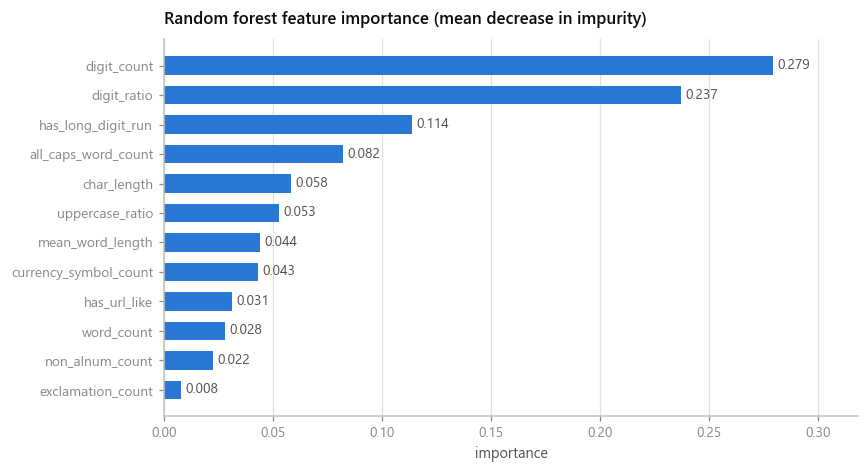

In [15]:
importances = pd.Series(forest.feature_importances_, index=X_train.columns)
importances = importances.sort_values(ascending=False)

print("random forest feature importances (mean decrease in impurity):\n")
for rank, (name, value) in enumerate(importances.items(), 1):
    bar = "#" * int(round(value * 120))
    print(f"  {rank:>2}. {name:<24} {value:.4f}  {bar}")
print(f"\ntop 3 account for {importances.head(3).sum():.1%} of total importance")

fig, ax = plt.subplots(figsize=(8.0, 4.4))
ordered = importances.sort_values()
ax.barh(ordered.index, ordered.to_numpy(), color=SERIES[0], height=0.62)
annotate_bars(ax, fmt="{:.3f}", horizontal=True)
ax.set_title("Random forest feature importance (mean decrease in impurity)")
ax.set_xlabel("importance")
ax.grid(axis="y", visible=False)
despine(ax)
plt.tight_layout()
plt.show()

> **A caveat on impurity-based importance.** It is biased toward high-cardinality
> features — a continuous column like `char_length` offers a tree far more candidate
> split points than a binary flag like `has_url_like`, so it accumulates importance
> partly for that reason rather than purely on merit. The binary flags are therefore
> understated here relative to how much they actually contribute. Permutation
> importance on the held-out set would not have that bias; it is left out to keep the
> notebook to the brief's scope, and the ranking below should be read as indicative
> rather than exact.

### 6.5 Where the model fails

In [16]:
predictions = forest.predict(X_test)
# test_meta carries the raw text through the split, index-aligned to test_X.
test_rows = split.test_X.join(split.test_meta)
test_rows["actual"] = y_test.to_numpy()
test_rows["predicted"] = predictions
test_rows["p_spam"] = probabilities

missed = test_rows[(test_rows.actual == SPAM) & (test_rows.predicted == HAM)]
misfiled = test_rows[(test_rows.actual == HAM) & (test_rows.predicted == SPAM)]

print(f"spam missed (false negatives): {len(missed)}")
for _, row in missed.sort_values("p_spam").head(4).iterrows():
    print(f"   p(spam)={row.p_spam:.2f}  len={int(row.char_length):>3}  "
          f"digits={int(row.digit_count):>2}  {redact(row.message, max_chars=58)}")

print(f"\nham misfiled (false positives): {len(misfiled)}")
for _, row in misfiled.sort_values("p_spam", ascending=False).head(4).iterrows():
    print(f"   p(spam)={row.p_spam:.2f}  len={int(row.char_length):>3}  "
          f"digits={int(row.digit_count):>2}  {redact(row.message, max_chars=58)}")

spam missed (false negatives): 13
   p(spam)=0.00  len= 81  digits= 1  <NAME> one ringtone and now getting texts costing <NUM> p…
   p(spam)=0.04  len= 69  digits= 0  <NAME> Out <NAME> Your <NAME> <NAME> @ sms.shsex.netUN fg…
   p(spam)=0.07  len= 84  digits= 0  Would you like to see my XXX pics they are so hot they we…
   p(spam)=0.15  len=141  digits= 2  <NAME> <NAME> - <NAME> play footy at a top stadium? Get <…

ham misfiled (false positives): 1
   p(spam)=0.97  len=151  digits= 8  <NUM> wonders in My WORLD 7th You 6th Ur style 5th Ur smi…


This is the LIMITATIONS section made concrete. The missed spam is the spam that
*looks* like ham on all twelve axes — short, few digits, no URL, no shouting. Nothing
in the feature set can catch it, because the only thing marking it as spam is what the
words mean.

## 7. LIMITATIONS

### 7.1 The features capture message shape, not word identity — and that caps recall

Every one of the twelve features is a count, a ratio or a flag over *characters*. The
model can see that a message is 150 characters long, 12% digits, contains a URL and
shouts twice. It cannot see that the words are `FREE`, `WINNER` and `CLAIM`.

The consequence is a **hard ceiling on recall**, and it is visible in section 6.5: the
false negatives are spam messages whose shape is indistinguishable from ham. A short,
politely-worded, digit-free scam — *"Hi, is this still available? Please reply"* — has
the same twelve feature values as a genuine text from a friend. **No amount of extra
training data or tuning fixes this**, because the information needed to separate those
two messages was discarded at feature-engineering time and never reaches the model.

**The cost is concentrated in recall, and the numbers show it.** The forest reaches
spam precision 0.992 — when it flags a message it is almost always right — but recall
only 0.901. Roughly one spam message in ten gets through, and section 6.5 shows they
are the ones that read like ordinary text. Precision is high because the shape signals
it *does* have (a long digit run, a URL, a currency symbol) are close to conclusive
when present; recall is capped because they are frequently absent.

Published TF-IDF/naive-Bayes results on this corpus generally report spam recall
around 0.93–0.97, against 0.90 here, and that difference is roughly the measurable
value of word identity on this task. The trade is not one-sided: twelve integer
features are far cheaper to compute than a sparse term matrix, carry no vocabulary to
store, version or maintain, do not degrade as vocabulary drifts, and stay legible —
section 6.4 is a twelve-row table, not a 5,000-dimensional weight vector. But recall
is the price, and it is paid in spam that reaches the inbox.

### 7.2 The currency and uppercase features assume English and Latin script

Two features encode assumptions that hold for this corpus and break outside it.

**`currency_symbol_count`** looks for `$ £ € ¥ ₹ ¢ ₩ ₽ ₪ ₦ ฿`. Arabic-script text
writes currency as `د.إ`, `ر.س` or `ج.م` — letter sequences, not symbols — and the
Arabic comma `،` and Arabic-Indic digits `٠١٢٣٤٥٦٧٨٩` are outside the ASCII ranges the
other features test. On Arabic SMS spam, this feature would read **zero for every
message in the corpus**, spam and ham alike. A feature with no variance contributes
nothing; the model would silently lose one of its twelve inputs, and section 6.4 shows
`currency_symbol_count` is not a spare one.

**`uppercase_ratio` and `all_caps_word_count` are worse than useless outside Latin
script**, because they are not merely uninformative — they are undefined. Arabic,
Hebrew, Chinese, Japanese, Korean, Thai and Devanagari are **unicameral**: they have no
case distinction at all. `str.isupper()` returns `False` for every character in
`مبروك! ربحت جائزة`, so both features read 0 regardless of how emphatic the message is.
Emphasis in Arabic is carried by elongation (`مبروووووك`), repeated punctuation, or
diacritics — signals these features cannot see. Two of twelve features would be dead
inputs.

**Arabizi is the case that breaks the assumption hardest.** Arabic written in Latin
characters with digits standing in for Arabic letters — `3` for ع, `7` for ح, `2` for
ء, `5` for خ — is how a large share of informal SMS in the Levant and Gulf is actually
written. `"mabrouk! rb7t jaizeh, 7awel 3ala 3asharat alaf"` is ordinary Arabizi, and
the twelve features read it as **heavily digit-laden**: `digit_count` and `digit_ratio`
are the two strongest features in the model (section 6.4), and here they fire on
ordinary conversational text. The direction of the error is the damaging one — Arabizi
ham gets pushed toward the spam side of the boundary, producing **false positives on
legitimate messages**, which section 6.2 identifies as the more costly error type. A
filter trained on this corpus and deployed on Arabizi traffic would misfile normal
conversation as spam, systematically, for a whole population of users.

`has_long_digit_run` degrades more gently — an 8-digit run is still unusual in Arabizi
— but `digit_ratio` and `digit_count` would need to be redefined over
non-Arabizi-substitution digits, or dropped, before this model could be used on that
traffic.

### 7.3 Narrower caveats

- **The corpus is old and narrow.** UK/Singapore SMS, largely 2000s-era. Message
  conventions, shortcode formats and spam tactics have all moved on.
- **Impurity-based importances are biased** toward high-cardinality features (see 6.4).
- **No hyperparameter search and no cross-validation.** Every number here is one
  fixed 80/20 split, so it carries sampling noise that a single number hides. With
  ~131 spam messages in the test set, one additional catch moves recall by ~0.8 points.
  Repeated stratified k-fold would give an interval rather than a point.
- **`class_weight` was left at `None`.** The precision–recall curve in 6.3 shows the
  frontier this decision picks a point on.
- **De-duplication was exact-match only.** Near-duplicates differing by one character
  survive into both partitions and would inflate the score slightly; the honest fix is
  fuzzy matching before the split, which is out of scope here.

## 8. Summary

In [17]:
final = results[results.Model != "Baseline (most frequent)"].copy()
baseline_row = results[results.Model == "Baseline (most frequent)"].iloc[0]

print("=" * 84)
print("SMS SPAM CLASSIFICATION — FINAL RESULTS (held-out test set)")
print("=" * 84)
print(f"corpus            : {before:,} messages -> {len(split.train.X) + len(split.test_X):,} "
      f"after dropping {split.n_duplicates_dropped} exact duplicates")
print(f"split             : {len(split.train.X):,} train / {len(split.test_X):,} test, "
      f"stratified, random_state={RANDOM_STATE}")
print(f"features          : {len(FEATURE_ORDER)} numerical, engineered from raw text")
print()
for _, row in final.iterrows():
    print(f"{row['Model']}")
    print(f"    spam precision {row['Precision (spam)']:.4f}   "
          f"spam recall {row['Recall (spam)']:.4f}   "
          f"spam F1 {row['F1 (spam)']:.4f}")
    print(f"    accuracy {row['Accuracy']:.4f}  "
          f"(baseline {baseline_row['Accuracy']:.4f} — see section 6.1)")
print()
print(f"top features      : {', '.join(importances.head(3).index)}")
print("=" * 84)

SMS SPAM CLASSIFICATION — FINAL RESULTS (held-out test set)
corpus            : 5,574 messages -> 5,171 after dropping 403 exact duplicates
split             : 4,136 train / 1,035 test, stratified, random_state=42
features          : 12 numerical, engineered from raw text

Decision tree
    spam precision 0.9219   spam recall 0.9008   spam F1 0.9112
    accuracy 0.9778  (baseline 0.8734 — see section 6.1)
Random forest (200 trees)
    spam precision 0.9916   spam recall 0.9008   spam F1 0.9440
    accuracy 0.9865  (baseline 0.8734 — see section 6.1)

top features      : digit_count, digit_ratio, has_long_digit_run
